<a href="https://colab.research.google.com/github/mariagio98/Superstore_Profit_Analysis/blob/main/notebook2_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ΕΡΓΑΣΙΑ: Big Data Analytics & Visualization for FinTech
**Θέμα:** Ανάλυση τάσεων ηλεκτρονικών πληρωμών στην Ελλάδα

**Παραλήπτης:** Product Team FinTech εταιρείας

---
## NOTEBOOK 2: Υπολογισμός KPIs & Οπτικοποιήσεις

In [1]:
# Εισαγωγή βιβλιοθηκών για ανάλυση και οπτικοποίηση
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ρυθμίσεις εμφάνισης γραφημάτων
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
print(' Βιβλιοθήκες φορτώθηκαν!')

 Βιβλιοθήκες φορτώθηκαν!


In [2]:
# Φόρτωμα του καθαρού dataset από το Notebook 1
from google.colab import files
uploaded = files.upload()
# --> Διαλέξτε το αρχείο: bog_payments_clean.csv

Saving bog_payments_clean.csv to bog_payments_clean.csv


In [3]:
# Ανάγνωση του καθαρού dataset
df = pd.read_csv('bog_payments_clean.csv')
print('Dataset φορτώθηκε επιτυχώς!')
df

Dataset φορτώθηκε επιτυχώς!


,Έτος,Αριθμός_Καρτών,POS_Τερματικά,Συναλλαγές_Εκατ,Αξία_Εκατ_Ευρώ,Μεταφορές_Πιστώσεων_Εκατ,Άμεσες_Χρεώσεις_Εκατ,Επιταγές_Εκατ
0,2014,13216197,194799,384.557000,8.915338e+05,179.600000,16.719000,8.951000
1,2015,14033501,219071,583.825000,7.878031e+05,240.893000,27.039000,7.491000
2,2016,14987182,422008,761.128000,7.077594e+05,288.880000,26.363000,7.451000
3,2017,17158502,544091,1035.977000,7.371076e+05,343.719000,17.727000,6.737000
4,2018,17869317,677628,1157.653000,6.627688e+05,334.551000,18.458000,6.326000
5,2019,18826198,750195,1304.962000,8.128627e+05,349.624000,19.533000,5.515000
6,2020,19190904,793528,1733.333000,7.956807e+05,474.082000,21.121000,4.344000
7,2021,20216637,836619,2103.496000,8.084549e+05,476.642000,25.887000,3.919000
8,2022,22426765,1049540,2406.040335,1.153391e+06,555.979574,31.335752,3.797906
9,2023,22203208,1184022,2599.041354,1.178335e+06,615.324541,32.623717,3.327198


## KPIs
Υπολογίζουμε 4 βασικούς δείκτες απόδοσης (KPIs) που απαντούν στο ερώτημα:
**ποιες κατηγορίες πληρωμών αναπτύσσονται γρηγορότερα στην Ελλάδα;**

In [4]:
# KPI 1: Συνολική αύξηση αριθμού καρτών (2014 vs 2022)
kartes_2014 = df.loc[df['Έτος'] == 2014, 'Αριθμός_Καρτών'].values[0]
kartes_2022 = df.loc[df['Έτος'] == 2022, 'Αριθμός_Καρτών'].values[0]
auxisi_kartes = ((kartes_2022 - kartes_2014) / kartes_2014) * 100

# KPI 2: Συνολική αύξηση αξίας συναλλαγών (2014 vs 2022)
axia_2014 = df.loc[df['Έτος'] == 2014, 'Αξία_Εκατ_Ευρώ'].values[0]
axia_2022 = df.loc[df['Έτος'] == 2022, 'Αξία_Εκατ_Ευρώ'].values[0]
auxisi_axia = ((axia_2022 - axia_2014) / axia_2014) * 100

# KPI 3: Μέσο ticket size ανά έτος (αξία / αριθμός συναλλαγών)
df['Ticket_Size_Euro'] = (df['Αξία_Εκατ_Ευρώ'] / df['Συναλλαγές_Εκατ'])

# KPI 4: Μείωση επιταγών (2014 vs 2022) - ευκαιρία ψηφιοποίησης
epitages_2014 = df.loc[df['Έτος'] == 2014, 'Επιταγές_Εκατ'].values[0]
epitages_2022 = df.loc[df['Έτος'] == 2022, 'Επιταγές_Εκατ'].values[0]
meiwsi_epitages = ((epitages_2022 - epitages_2014) / epitages_2014) * 100

print('=== KPIs: 2014 vs 2022 ===')
print(f'KPI 1 | Αύξηση αριθμού καρτών:       +{auxisi_kartes:.1f}%')
print(f'KPI 2 | Αύξηση αξίας συναλλαγών:     +{auxisi_axia:.1f}%')
print(f'KPI 3 | Μέσο ticket size 2022:        {df[df["Έτος"]==2022]["Ticket_Size_Euro"].values[0]:.0f} € ανά συναλλαγή')
print(f'KPI 4 | Μεταβολή επιταγών:            {meiwsi_epitages:.1f}%')

=== KPIs: 2014 vs 2022 ===
KPI 1 | Αύξηση αριθμού καρτών:       +69.7%
KPI 2 | Αύξηση αξίας συναλλαγών:     +29.4%
KPI 3 | Μέσο ticket size 2022:        479 € ανά συναλλαγή
KPI 4 | Μεταβολή επιταγών:            -57.6%


## Γράφημα 1 — Line Chart: Εξέλιξη αριθμού καρτών (2014–2022)
Δείχνει τη σταθερή ανοδική τάση στη χρήση καρτών, υποδεικνύοντας
αυξανόμενη αποδοχή ψηφιακών μεθόδων πληρωμής.

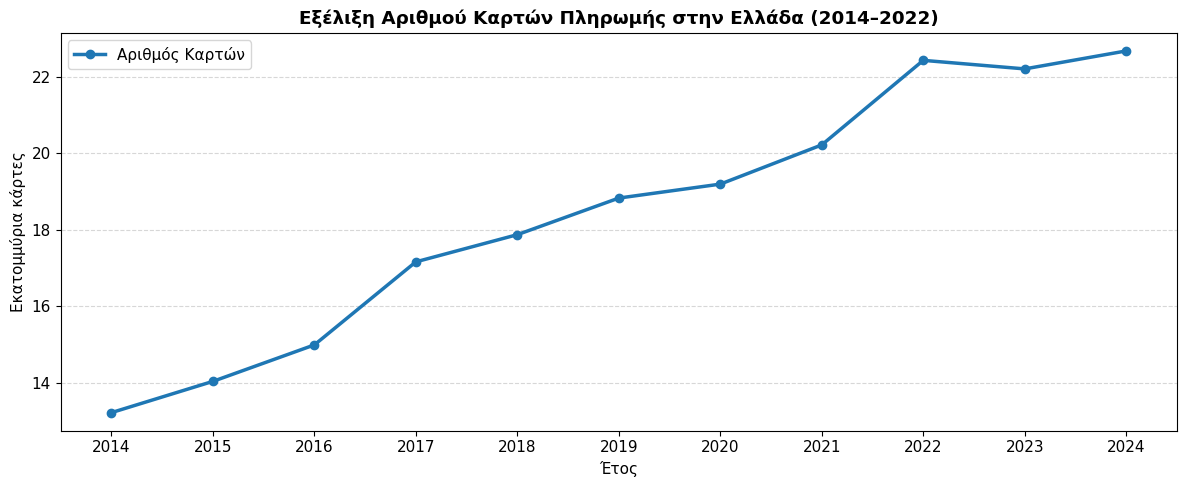

Εύρημα: Ο αριθμός καρτών αυξήθηκε κατά 69.7% από το 2014 έως το 2022.


In [5]:
fig, ax = plt.subplots()

ax.plot(df['Έτος'], df['Αριθμός_Καρτών'] / 1_000_000,
        marker='o', linewidth=2.5, color='#1f77b4', label='Αριθμός Καρτών')

ax.set_title('Εξέλιξη Αριθμού Καρτών Πληρωμής στην Ελλάδα (2014–2022)', fontweight='bold')
ax.set_xlabel('Έτος')
ax.set_ylabel('Εκατομμύρια κάρτες')
ax.set_xticks(df['Έτος'])
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig('chart1_kartes.png', dpi=150)
plt.show()
print('Εύρημα: Ο αριθμός καρτών αυξήθηκε κατά {:.1f}% από το 2014 έως το 2022.'.format(auxisi_kartes))

## Γράφημα 2 — Bar Chart: Σύγκριση μεθόδων πληρωμής (2022)
Συγκρίνει τον όγκο (εκατ. συναλλαγών) ανά μέθοδο πληρωμής το 2022,
αναδεικνύοντας ποιες κατηγορίες κυριαρχούν και πού υπάρχουν ευκαιρίες.

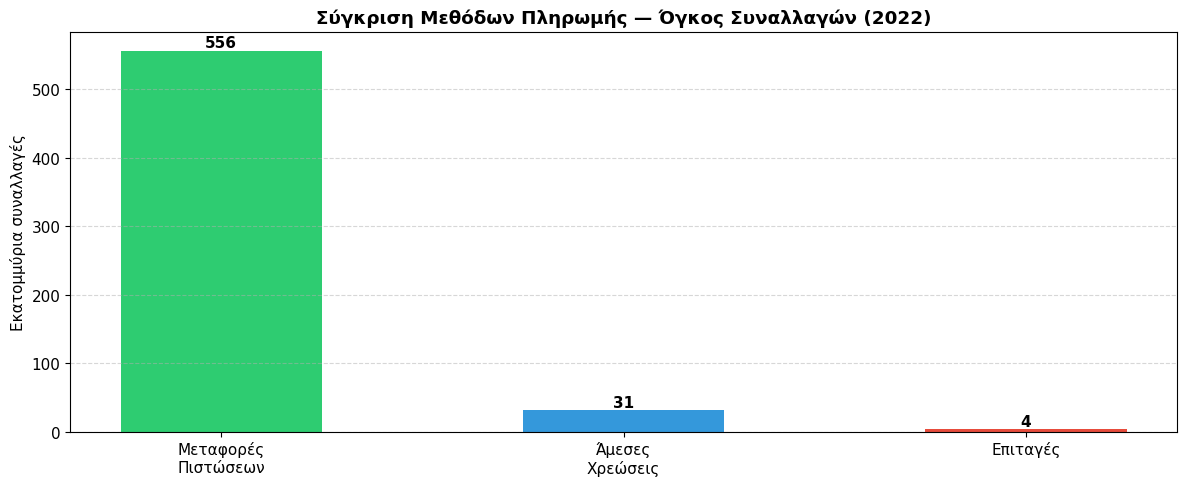

Εύρημα: Οι μεταφορές πιστώσεων κυριαρχούν, ενώ οι επιταγές είναι σε σταθερή πτώση.


In [6]:
# Δεδομένα για το 2022
df_2022 = df[df['Έτος'] == 2022].iloc[0]

methodi = ['Μεταφορές\nΠιστώσεων', 'Άμεσες\nΧρεώσεις', 'Επιταγές']
times = [
    df_2022['Μεταφορές_Πιστώσεων_Εκατ'],
    df_2022['Άμεσες_Χρεώσεις_Εκατ'],
    df_2022['Επιταγές_Εκατ']
]
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, ax = plt.subplots()
bars = ax.bar(methodi, times, color=colors, width=0.5)

# Προσθήκη τιμών πάνω από κάθε μπάρα
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}', ha='center', fontweight='bold')

ax.set_title('Σύγκριση Μεθόδων Πληρωμής — Όγκος Συναλλαγών (2022)', fontweight='bold')
ax.set_ylabel('Εκατομμύρια συναλλαγές')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart2_methodi.png', dpi=150)
plt.show()
print('Εύρημα: Οι μεταφορές πιστώσεων κυριαρχούν, ενώ οι επιταγές είναι σε σταθερή πτώση.')

## Γράφημα 3 — Composition Chart: Εξέλιξη mix μεθόδων πληρωμής (2014–2022)
Δείχνει πώς άλλαξε η σύνθεση των πληρωμών με την πάροδο του χρόνου.
Η μείωση των επιταγών και η άνοδος των ψηφιακών μεθόδων είναι σαφής ευκαιρία για FinTech προϊόντα.

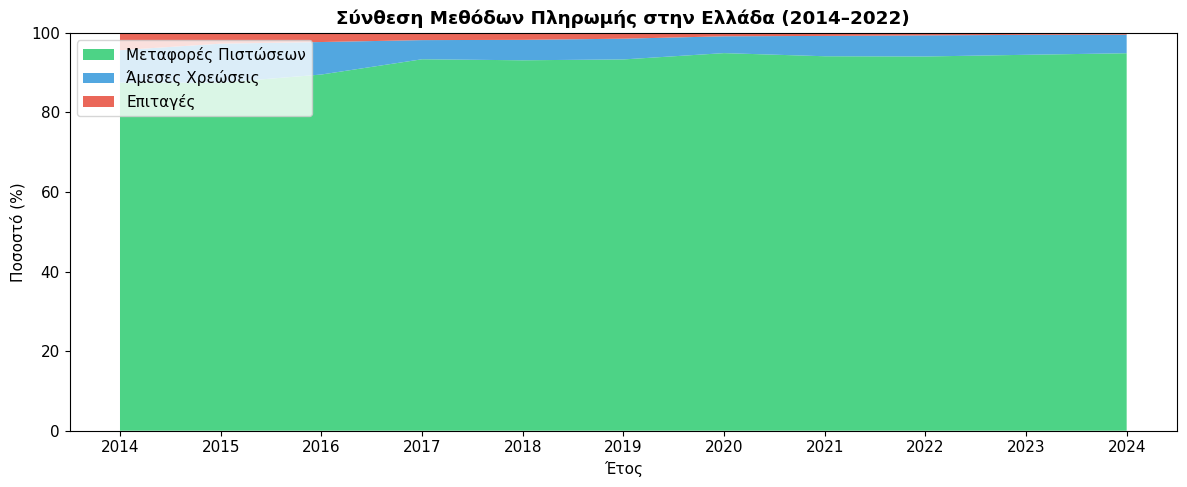

Εύρημα: Οι επιταγές μειώνονται σταδιακά, αντικαθιστώμενες από ψηφιακές μεθόδους.


In [7]:
# Υπολογισμός ποσοστών ανά μέθοδο για κάθε έτος
df['Σύνολο_Μεθόδων'] = (df['Μεταφορές_Πιστώσεων_Εκατ'] +
                         df['Άμεσες_Χρεώσεις_Εκατ'] +
                         df['Επιταγές_Εκατ'])

df['%_Μεταφορές']  = df['Μεταφορές_Πιστώσεων_Εκατ'] / df['Σύνολο_Μεθόδων'] * 100
df['%_Άμεσες']     = df['Άμεσες_Χρεώσεις_Εκατ']     / df['Σύνολο_Μεθόδων'] * 100
df['%_Επιταγές']   = df['Επιταγές_Εκατ']              / df['Σύνολο_Μεθόδων'] * 100

fig, ax = plt.subplots()

ax.stackplot(df['Έτος'],
             df['%_Μεταφορές'], df['%_Άμεσες'], df['%_Επιταγές'],
             labels=['Μεταφορές Πιστώσεων', 'Άμεσες Χρεώσεις', 'Επιταγές'],
             colors=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.85)

ax.set_title('Σύνθεση Μεθόδων Πληρωμής στην Ελλάδα (2014–2022)', fontweight='bold')
ax.set_xlabel('Έτος')
ax.set_ylabel('Ποσοστό (%)')
ax.set_xticks(df['Έτος'])
ax.legend(loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('chart3_composition.png', dpi=150)
plt.show()
print('Εύρημα: Οι επιταγές μειώνονται σταδιακά, αντικαθιστώμενες από ψηφιακές μεθόδους.')

In [ ]:
# Κατέβασμα γραφημάτων στον υπολογιστή
files.download('chart1_kartes.png')
files.download('chart2_methodi.png')
files.download('chart3_composition.png')
print('✅ Τα 3 γραφήματα κατέβηκαν επιτυχώς!')